# Approximating pi

**Author:** Pratham Bhargava  
**Date:** 2026-04-15

We approximate $\pi$ by finding the area of a n-polygon inscribed in a unit circle, which we denote by $a_n$, and the area of a n-polygon circumscribed in the same circle, which we denote by $A_n$. 

By constructing a right angle triangle using the centre of the inscribed n-polygon, $P_1$, a vertex of $P_1$ and the midpoint of a side of $P_1$ adjacent to this vertex, we obtain $a_n = n \sin(\frac{\pi}{n}) \cos(\frac{\pi}{n})$. Similarly, by constructing a right triangle using the centre of the circumscribed n-polygon, $P_2$, a vertex of $P_2$ and the midpoint of a side of $P_2$ adjacent to this vertex, we obtain $A_n = n \tan{\frac{\pi}{n}}$. 

Now we use the following recurrence relations: 

$$
\begin{align}
    a_{2n} & = \sqrt{a_n A_n }, \\
    A_{2n} & = \frac{2 a_{2n} A_n}{a_{2n} + A_n}.
\end{align}
$$

Equation (1) follows from the equation $\sin{\frac{\pi}{n}} = 2\sin{\frac{\pi}{n}} \cos{\frac{\pi}{n}}$. We take the postive root since $a_n > 0$ for all $n$. To obtain equation (2), via the double-anlge formulae for $\sin{\frac{\pi}{n}}$ and $\cos{\frac{\pi}{n}}$, we have

$$
\begin{align*}
    A_{2n} & = \frac{2n \sin{\frac{\pi}{2n}}}{\cos{\frac{\pi}{2n}}} \\
    & = \frac{n \sin{\frac{\pi}{n}}}{\cos^2{\frac{\pi}{2n}}} \\
    & = \frac{2n\sin{\frac{\pi}{n}}}{\cos{\frac{\pi}{n}} + 1} \\
    & = \frac{2n^2\sin^2{\frac{\pi}{n}}}{n\sin{\frac{\pi}{n}}\cos{\frac{\pi}{n}} + n\sin{\frac{\pi}{n}}} \\
    & = \frac{2n^2\sin{\frac{\pi}{n}}\tan{\frac{\pi}{n}}}{n\sin{\frac{\pi}{n}} + n\tan{\frac{\pi}{n}}} \\
    & = \frac{2(2n\sin{\frac{\pi}{2n}}\cos{\frac{\pi}{2n}})(n\tan{\frac{\pi}{n}})}{2n\sin{\frac{\pi}{2n}}\cos{\frac{\pi}{2n}} + n\tan{\frac{\pi}{n}}}
\end{align*}
$$

as required. Also, I've implemented the algorithm in Python below.

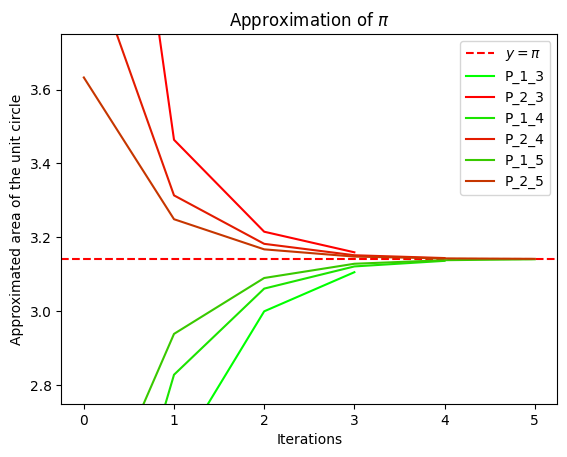

                         Value, n = 3 (to 5.d.p) Value, n = 4 (to 5.d.p)  \
Approximation using P_1:                 3.10583                 3.13655   
Approximation using P_2:                 3.15966                 3.14412   
Actual value of pi:                      3.14159                 3.14159   

                         Value, n = 5 (to 5.d.p)  
Approximation using P_1:                 3.14079  
Approximation using P_2:                 3.14200  
Actual value of pi:                      3.14159  


In [1]:
%matplotlib inline
from math import pi, sin, cos, tan, sqrt
import matplotlib.pyplot as plt
import pandas as pd


def main():
    n = 5
    d = 5 # number of decimal places
    dict_ = {}

    for j in range(3, n + 1):
        dict_["num_a0" + f"_{j}"] = calc_an(j)
        dict_["num_A0" + f"_{j}"] = calc_An(j)

    final_vals_a, final_vals_A = create_graph(n, dict_)

    df = pd.DataFrame({
        "Approximation using P_1:": [f"{num_an:.{d}f}" for num_an in final_vals_a], 
        "Approximation using P_2:": [f"{num_An:.{d}f}" for num_An in final_vals_A],
        "Actual value of pi:": [f"{pi:.{d}f}"] * len(final_vals_a)
    }).T

    df.columns = [f"Value, n = {j} (to {d}.d.p)" for j in range(3, n + 1)]
    print(df)

def a2(a1, a2):
    return sqrt(a1*a2)

def A2(a1, a2):
    return (2*a1*a2)/(a1+a2)

def calc_an(n):
    return n*sin(pi/n)*cos(pi/n)

def calc_An(n):
    return n*tan(pi/n)

def find_new_area(j, num_an, num_An):
    for _ in range(j):
        num_a2n = a2(num_an, num_An)
        num_A2n = A2(num_a2n, num_An)
        num_an = num_a2n
        num_An = num_A2n

        yield num_a2n, num_An

def create_graph(n, dict_):
    fig, ax = plt.subplots()
    ax.axhline(y=pi, color="r", linestyle="--", label=r"$y = \pi$")
    final_vals_a, final_vals_A = [], []
    colors_a = [(0 + i / ((n - 2) * 3), 1 - i / ((n - 2) * pi), 0) for i in range(n - 2)]
    colors_A = [(1 - i / ((n - 2) * 3), 0 + i / ((n - 2) * pi), 0) for i in range(n - 2)]

    for j in range(3, n + 1):
        num_a0 = dict_["num_a0" + f"_{j}"]
        num_A0 = dict_["num_A0" + f"_{j}"]
        gen = find_new_area(j, num_a0, num_A0)

        y_1, y_2 = map(list, zip(*gen))
        y_1.insert(0, num_a0)
        final_vals_a.append(y_1[-1])

        y_2.insert(0, num_A0)
        final_vals_A.append(y_2[-1])

        x = list(range(len(y_1)))

        ax.plot(x, y_1, color=colors_a[j - 3], label="P_1" + f"_{j}")
        ax.plot(x, y_2, color=colors_A[j - 3], label="P_2" + f"_{j}")

    ax.set_title(rf"Approximation of $\pi$")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Approximated area of the unit circle")
    ax.legend()
    
    ax.set_ylim(2.75, 3.75) 
    plt.show()

    return (final_vals_a, final_vals_A)

main()